In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import matplotlib as mpl
import pandas as pd
import json
import sys
import os
from glob import glob
import h5py
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.family'] = 'serif'
# mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['font.size'] = 9


from sample_factory.utils.utils import log

In [2]:
def colored_line_between_pts(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified between (x, y) points by a third value.

    It does this by creating a collection of line segments between each pair of
    neighboring points. The color of each segment is determined by the
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should have a size one less than that of x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        log.warn('The provided "array" keyword argument will be overridden')

    # Check color array size (LineCollection still works, but values are unused)
    if len(c) != len(x) - 1:
        log.warn(
            "The c argument should have a length one less than the length of x and y. "
            "If it has the same length, use the colored_line function instead."
        )

    # Create a set of line segments so that we can color them individually
    # This creates the points as an N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, **lc_kwargs)

    # Set the values used for colormapping
    lc.set_array(c)

    return ax.add_collection(lc)

In [3]:
rootpath = "/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalRewardSeparateReward/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "01_InternalReward01_see_22/"
# experiment_name = "02_InternalReward01_see_333/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "00_InternalReward04_see_11/"
# experiment_name = "01_InternalReward04_see_22/"
# experiment_name = "02_InternalReward04_see_333/"
# experiment_name = "03_InternalReward04_see_4444/"
# experiment_name = "04_InternalReward04_see_55555/"
experiment_name = "00_InternalReward06_see_12/"
# experiment_name = "01_InternalReward06_see_23/"
# experiment_name = "02_InternalReward06_see_34/"
# experiment_name = "03_InternalReward06_see_45/"
experiment_name = "0_5/"
telemetry_list_csv = glob(str(rootpath + experiment_name + "telemetry/*.csv"))
telemetry_list_h5 = glob(str(rootpath + experiment_name + "telemetry/*.h5"))
print(telemetry_list_csv)

['/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalRewardSeparateReward/0_5/telemetry/pose_20251107_175156.csv']


In [4]:
pddata = pd.read_csv(telemetry_list_csv[0])
with h5py.File(telemetry_list_h5[0]) as h5:
    activations = {k: h5[k][...] for k in h5}

In [5]:
pddata

,frame,agent,x,y,z,rot_x,rot_y,rot_z,num_traj,info
0,0,0,1463.187744,330.260895,25.125,0.0,-65.324707,0.0,0,"{""num_frames"": 8}"
1,1,0,1483.873779,293.678711,25.125,0.0,-48.427734,0.0,0,"{""num_frames"": 8}"
2,2,0,1483.874756,251.384476,25.125,0.0,-65.324707,0.0,0,"{""num_frames"": 8}"
3,3,0,1483.874390,232.596161,25.125,0.0,-65.324707,0.0,0,"{""num_frames"": 8}"
4,4,0,1483.874146,239.279907,25.125,0.0,-65.324707,0.0,0,"{""num_frames"": 8}"
...,...,...,...,...,...,...,...,...,...,...
49996,49996,0,1693.956787,1940.480103,25.125,0.0,120.492554,0.0,55,"{""num_frames"": 8}"
49997,49997,0,1648.804077,1944.344604,25.125,0.0,120.492554,0.0,55,"{""num_frames"": 8}"
49998,49998,0,1607.484985,1957.458008,25.125,0.0,137.389526,0.0,55,"{""num_frames"": 8}"
49999,49999,0,1572.083862,1982.462891,25.125,0.0,120.492554,0.0,55,"{""num_frames"": 8}"


In [6]:
activations['encoder.DG_projection.linear'].shape

(50001, 16)

In [7]:
activations['core'][:,:-13:10]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [8]:
hippo_n_feature = 16
length = 71

In [9]:
tmp_act=activations
sids=tmp_act['core'][:,:-13:length]


xbound=(100,2000)
ybound=(100,2000)
grain = 19
occu_xy=np.histogramdd((pddata['x'],
                         pddata['y']),
                         (np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1)),
                         density=False)[0]




grain=19
seq0_xya=np.zeros((grain,grain,hippo_n_feature))
for i in range(hippo_n_feature):
    print(i)
    seq0_xya[:,:,i]=np.histogramdd((pddata['x'],
                                      pddata['y']),
                                      (np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1)),
                                      weights=sids[:,i],
                                      density=False)[0]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


In [14]:
sids.shape

(50001, 16)

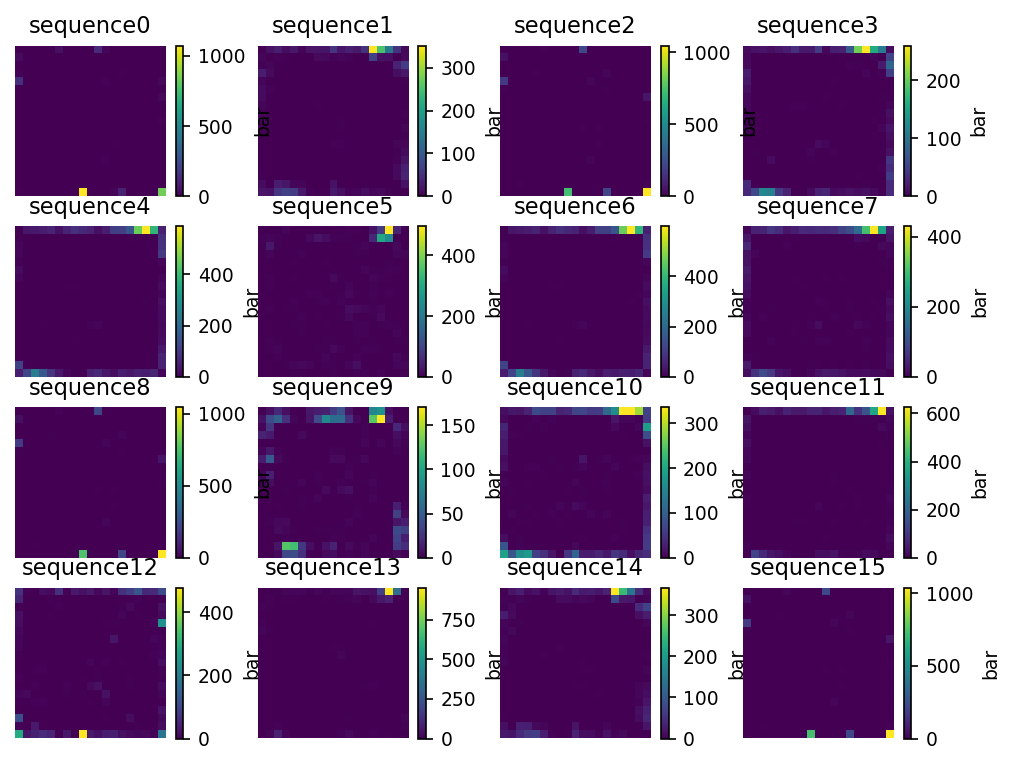

In [10]:
fig,ax = plt.subplots(4,4, figsize=(8,6), dpi=150)
ax = ax.flatten()
for i in range(hippo_n_feature):#np.nonzero(SI_mlp2>0.2)[0]:
    ax[i].set_title(f"sequence{i}")
    tmp=seq0_xya[:,:,i].T
    # tmp[tmp<1e-30]=np.nan
    line = ax[i].imshow(tmp,extent=[100,2000,100,2000],origin='lower',cmap='viridis')
    ax[i].set_axis_off()
    fig.colorbar(line, ax=ax[i], label="bar")

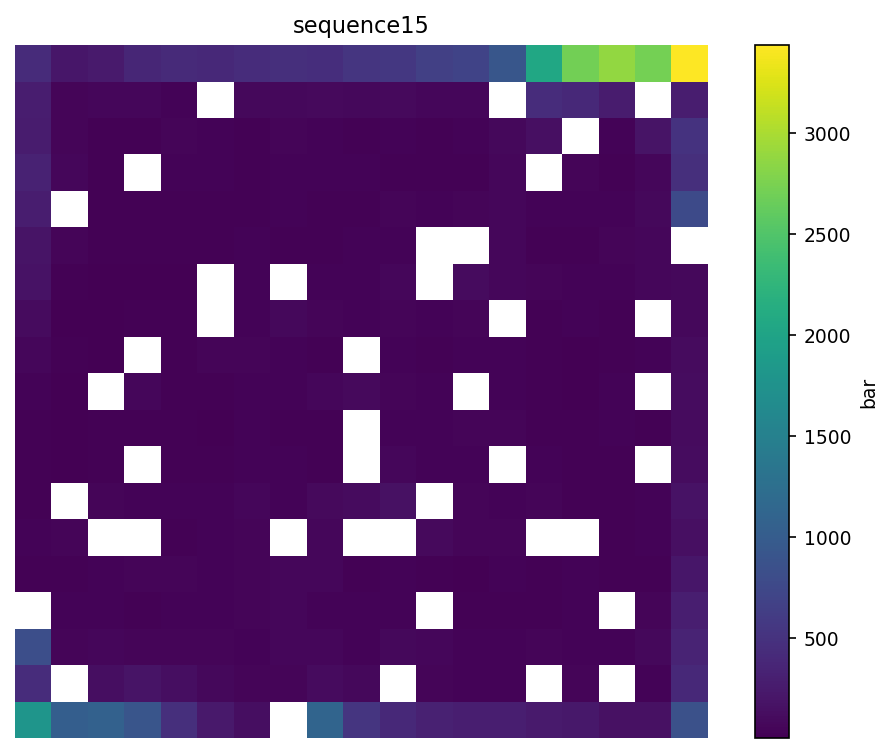

In [12]:
fig,ax = plt.subplots(1,1, figsize=(8,6), dpi=150)
# ax = ax.flatten()
# for i in range(hippo_n_feature):#np.nonzero(SI_mlp2>0.2)[0]:
ax.set_title(f"sequence{i}")
tmp=occu_xy[:,:].T
tmp[tmp<1e-30]=np.nan
line = ax.imshow(tmp,extent=[100,2000,100,2000],origin='lower',cmap='viridis')
ax.set_axis_off()
fig.colorbar(line, ax=ax, label="bar")

In [13]:
start = 0
stop = 50000

colordata = np.linspace(start,stop-1,stop-start-1)

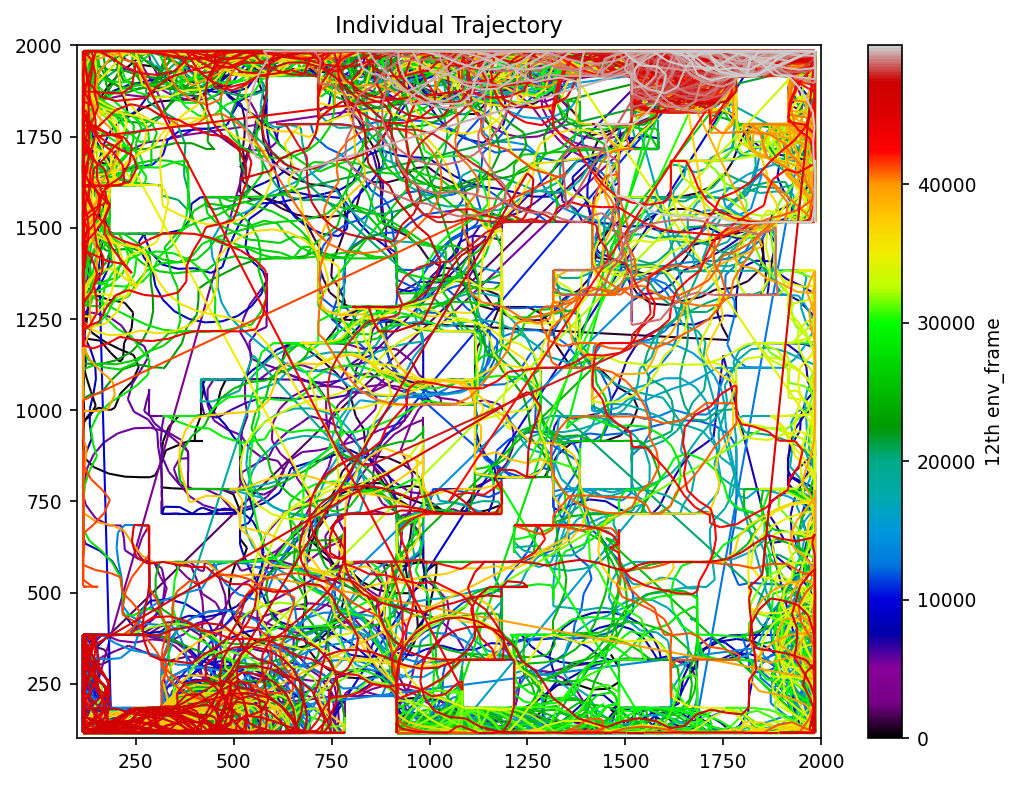

<Figure size 640x480 with 0 Axes>

In [14]:
fig2,ax2 = plt.subplots(1, 1, figsize=(8,6), dpi=150)
# ax = ax.flatten()
# for i in range(4):#np.nonzero(SI_mlp2>0.2)[0]:
    # ax[i].set_title(f"sequence{i}")
line = colored_line_between_pts(pddata["x"][start:stop], pddata["y"][start:stop],c=colordata, ax=ax2, linewidth=1, cmap="nipy_spectral")
fig2.colorbar(line, ax=ax2, label="12th env_frame")
# plt.axis("equal")

# ax2.set_xlim(xbound)
# ax2.set_ylim(ybound)
ax2.set_title("Individual Trajectory")



# plt.axis("equal")

plt.xlim(xbound)
plt.ylim(ybound)

plt.show()
plt.savefig('traj.png')

In [15]:
a = np.arange(0,600,1)
b = a+1
print(a,b)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

In [ ]:
pddata["x"][b].to_numpy()

In [ ]:
np.sqrt((pddata["x"][b].to_numpy()-pddata["x"][a].to_numpy())**2+(pddata["y"][b].to_numpy()-pddata["y"][a].to_numpy())**2)

In [ ]:
pddata["y"]

In [ ]:
# fig,ax = plt.subplots(1, 1, figsize=(6,6), dpi=150)
# # ax = ax.flatten()
# # for i in range(4):#np.nonzero(SI_mlp2>0.2)[0]:
#     # ax[i].set_title(f"sequence{i}")
# ax.scatter(pddata["x"], pddata["y"],c=np.linspace(0,pddata["x"].size,pddata["x"].size),cmap='viridis')
# # ax.set_axis_off()

In [ ]:
a = seq0_xya[:,:, :, np.newaxis]
b = seq0_xya[:,:, np.newaxis, :]

In [ ]:
difference = a-b

In [ ]:

for i in range(hippo_n_feature):#np.nonzero(SI_mlp2>0.2)[0]:
    fig,ax = plt.subplots(4,4, figsize=(8,6), dpi=150)
    ax = ax.flatten()
    for j in range(hippo_n_feature):
        ax[j].set_title(f"{i,j}")
        # print(difference[:,:,i,j])
        line = ax[j].imshow(difference[:,:,i,j],extent=[100,2000,100,2000],origin='lower',cmap='viridis')
        ax[j].set_axis_off()
        fig.colorbar(line, ax=ax[j], label="bar")
    fig.suptitle(f'Feature {i}')
    plt.show()